# Neural Network for Raman Spectroscopy Classification

## Introduction

Raman spectroscopy is an experimental technique that can be used to identify crystals and molecules. In the past a scientist would compare the spectra with with previoulsly labelled spectra or simulations. This project explores whether neural networks can be used to streamline the classification of spectra.

Raman spectra are one-dimensional and contain sharp peaks. These peaks could be features in the spectra that a neural network may use to differentiate between different materials.

## Load Modules

In [1]:
import os
import shutil
import random
from collections import defaultdict
import numpy as np

# Data visualisation modules
import matplotlib.pyplot as plt
import seaborn as sns

# Use Scipy when simulting Raman spectra
from scipy.special import voigt_profile

# Neural network built using TensorFlow
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.optimizers.legacy import Adam

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

## Simulate Raman spectra  

The data in this project will be simulated. The Raman modes will be voights. To give variety of spectra for a particular material the following will be varied:   
- Peak position: this simulates different calibrations of equipment as well as shift in peak position due to strain and temperature
- Peak width: Guassian broadening due to spectrometer quality
- Noise level: higher signal-to-noise can be achieved by, for example, longer acquisition times
- Fluorescence: Background fluorescence can significantly change the spectra

In [2]:
def raman_create(raman_modes, noise_level=0.001, add_fluorescence = True):
    # Define Raman shift range
    raman_shift = np.linspace(100, 2000, 2000)

    # Position shift - e.g. difference in spectrometer calibration, temperature effects
    shift = 2 * np.random.random()

    # Vary Gamma - e.g. different resolution's of detectors
    broad = 10*np.random.normal(0.5, 0.15)
    
    # Generate spectrum
    spectrum = np.zeros_like(raman_shift)
    for pos, intensity, sigma, gamma in raman_modes:
        spectrum += intensity * voigt_profile(raman_shift - pos - shift, broad*sigma, gamma)

    
    # Add fluorescence background
    if add_fluorescence:
        # Example: quadratic fluorescence curve
        fluorescence = 0.0000001 *(np.random.random()*raman_shift - 200)**2
        spectrum += fluorescence
    
    # Add noise
    noise = np.random.normal(0, noise_level, size=raman_shift.shape)
    spectrum_noisy = spectrum + noise

    
    # Normalize the spectrum
    spectrum_normalized = spectrum_noisy / (np.max(spectrum_noisy) +1e-8)

    
    # Combine into a two-column array
    raman_data = np.column_stack((raman_shift, spectrum_normalized))

    return raman_data

### Create data folders

In [3]:
names = ("sample_A", "sample_B", "sample_C",  "sample_D", "sample_E", "sample_F")

for name in names:
    directory = f"data/{name}"
    
    parent_dir = os.getcwd()
    path = os.path.join(parent_dir, directory)
    
    # Empty directory to prevent FileExistsError is the function is run several times
    if os.path.exists(path):
        shutil.rmtree(path)
        
    # Create top directory
    os.makedirs(path)
    path = os.path.join(parent_dir, directory)

### Guidance parameters

Below are some typical values for parameters that will be used when simulating the Raman spectra

#### Instrument Type - Typical σ (cm⁻¹)
High-resolution spectrometers 1–3 cm⁻¹  
Standard lab spectrometers 3–10 cm⁻¹  
Portable/handheld devices 10–20 cm⁻¹  

#### Material Type - Typical γ (cm⁻¹)
High-quality crystalline solids (e.g., Si, GaAs) 1–3 cm⁻¹  
Moderately disordered materials (e.g., polycrystalline graphite) 5–15 cm⁻¹  
Amorphous or heavily disordered materials (e.g., amorphous carbon, polymers) 15–50+ cm⁻¹  

#### Molecular TypeTypical γ (cm⁻¹)
Small, rigid molecules (e.g., benzene, CO₂) 1–5 cm⁻¹  
Medium-sized organics (e.g., toluene, aniline) 3–10 cm⁻¹  
Large or flexible molecules (e.g., proteins, polymers) 5–20+ cm⁻¹  

In [4]:
# Number of spectra per sample to be simulated
num_files = 50

# Define peak parameters: (position, intensity, sigma - instrument broadening, gamma - phonon lifetime)
sample_A = [
    (1000, 1.0, 1.4, 5),
    (1200, 0.8, 1.4, 4),
    (1400, 1.2, 1.4, 6),
    (1600, 0.9, 1.4, 3),
    (1800, 1.1, 1.4, 7),
    (1123, 1.2, 1.4, 6),
    (1450, 0.9, 1.4, 3),
    (1766, 1.1, 1.4, 7)
]

sample_B =[
    (520, 1.0, 1.4, 3),
    (1800, 1.2, 1.4, 6),
    (650, 1.0, 1.4, 3),
    (1700, 0.8, 1.4, 6),
    (1900, 1.2, 1.4, 6),
    (550, 1.0, 1.4, 3),
    (1500, 0.8, 1.4, 6),
    (1930, 1.2, 1.4, 6),
]

sample_C =[
    (200, 1.0, 1.4, 3),
    (210, 0.8, 1.4, 6),
    (280, 1.2, 1.4, 6),
    (300, 1.0, 1.4, 3),
    (310, 0.8, 1.4, 6),
    (333, 1.2, 1.4, 6),
    (370, 1.0, 1.4, 3),
    (387, 0.8, 1.4, 6),
    (408, 1.2, 1.4, 6),
]

sample_D =[
    (203, 1.0, 1.4, 3),
    (218, 0.8, 1.4, 3),
    (256, 1.2, 1.4, 3),
    (277, 1.0, 1.4, 3),
    (289, 0.8, 1.4, 3),
    (301, 1.2, 1.4, 3),
    (309, 1.0, 1.4, 3),
    (340, 0.8, 1.4, 3),
    (355, 1.2, 1.4, 3),
]

sample_E =[
    (1450, 1.0, 1.4, 10),
    (1550, 0.8, 1.4, 10),
    (1900, 1.2, 1.4, 10),
    (1920, 1.0, 1.4, 10),
    (1950, 0.8, 1.4, 10),
    (1980, 1.2, 1.4, 10),
]

sample_F =[
    (1000, 1.0, 1.4, 10),
    (1076, 0.8, 1.4, 10),
    (1090, 1.2, 1.4, 10),
    (1123, 1.0, 1.4, 10),
    (1405, 0.8, 1.4, 10),
    (1432, 1.2, 1.4, 10),
]

names = ("sample_A", "sample_B", "sample_C", "sample_D", "sample_E", "sample_F")
materials = [sample_A, sample_B, sample_C, sample_D, sample_E, sample_F]

for name, raman_modes in zip(names, materials):
    for i in range(num_files):
        if np.random.random() < 0.1:
            fluorescence = True
        else:
            fluorescence = False
            
        data = raman_create(raman_modes, noise_level=0.001, add_fluorescence = fluorescence)
        filename = f"data/{name}/output_{i}.txt"
        np.savetxt(filename, data)

### Display graphs of Raman spectra from one sample

In [5]:
def Graph_display(crystal, number = 50):
    '''
    A function to visualize the Raman spectra
    Parameters:
        Crystal - Type of material the Raman spectra belongs to
        number - Number of spectra to display
    '''
    # Index for iterating over images
    pic_index = 0

    # Directory containing the data
    dire = os.path.join(parent_dir, 'data/'+crystal)

    # Filenames
    name = os.listdir(dire)
    names = name[:number]

    # Parameters for our graph; we'll output images in a 4x4 configuration
    nrows = 10
    ncols = 5

    # Set up matplotlib fig, and size it to fit 4x4 pics
    fig = plt.gcf()
    fig.set_size_inches(ncols * 4, nrows * 4)

    # Create a list of all filenames
    pix = [os.path.join(dire, fname) for fname in names]

    for i, img_path in enumerate(pix):
        # Set up subplot; subplot indices start at 1
        sp = plt.subplot(nrows, ncols, i + 1)

        # Skip directories
        if os.path.isdir(img_path):
            continue

        # Load Raman spectra skipping the first row which contains labels
        img = np.loadtxt(img_path, skiprows=0)
        
        # Plot Raman spectra
        plt.plot(img[:,0],img[:,1])
        plt.xlabel('Raman Shift / $cm^{-1}$')
        plt.ylabel('Intensity / arb. units')
        plt.tight_layout()

    plt.show()

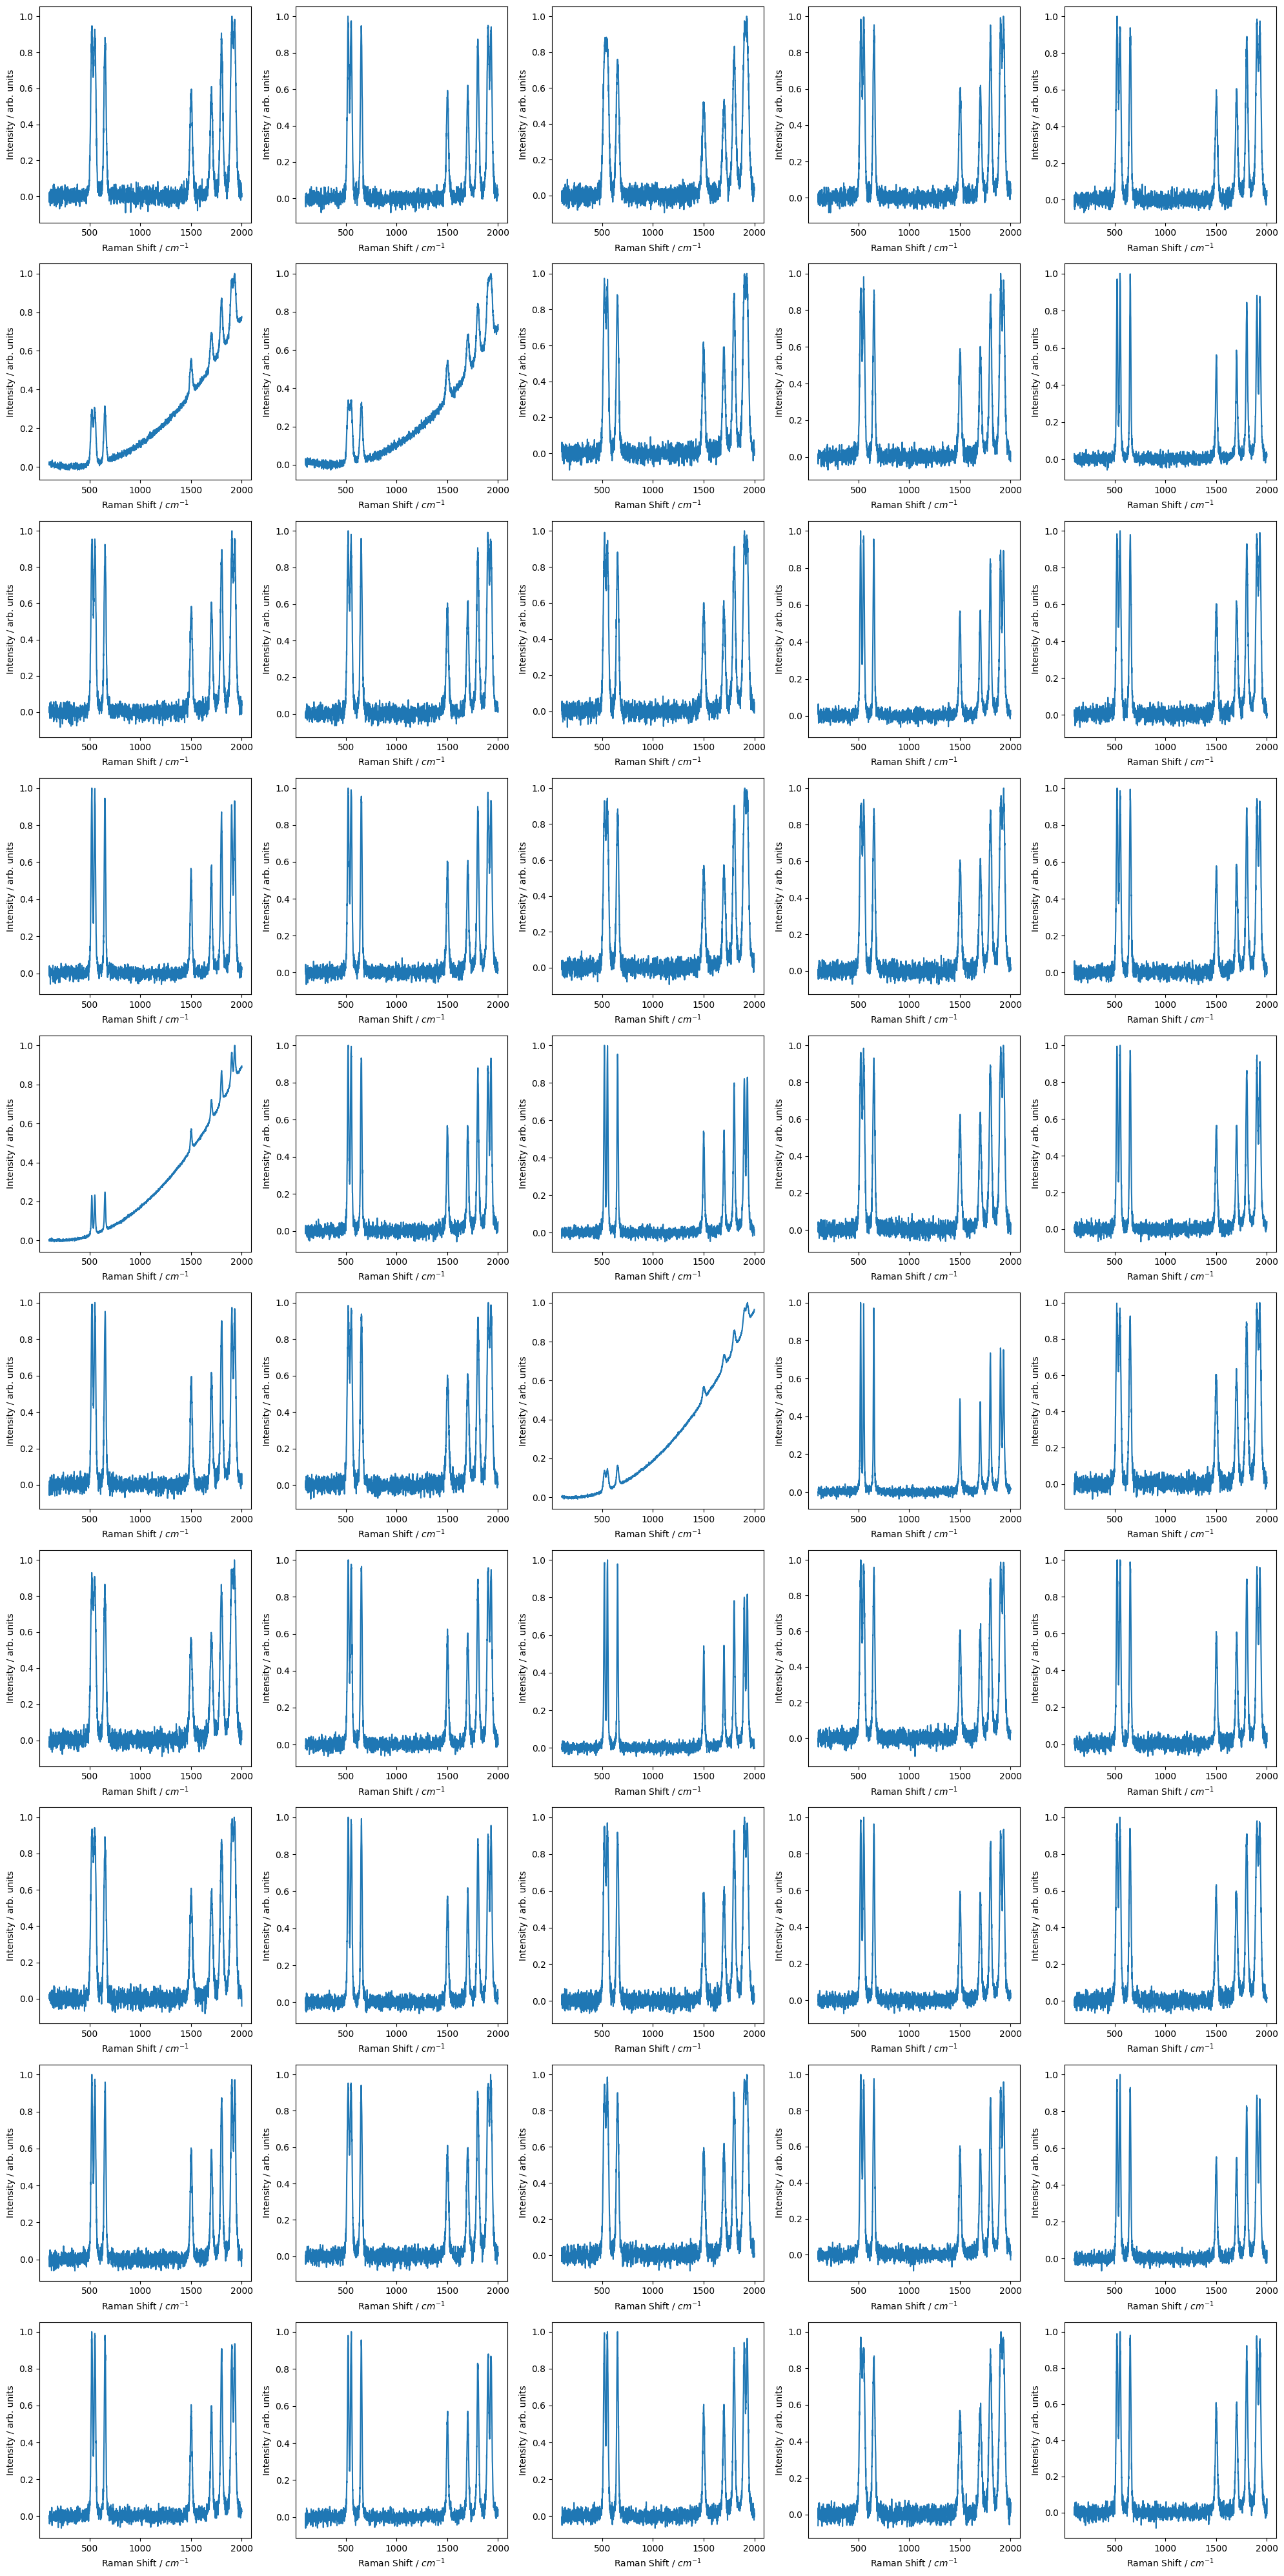

In [6]:
Graph_display("sample_B", number = 50)

## Prepare data for data generator

Folders are created for both "training" and "validation" data sets. Within these folders there will be folders for each samples.

In [7]:
def folder_creater(folder, directory, SPLIT_SIZE=0.8):
    parent_dir = os.getcwd()
    path = os.path.join(parent_dir, directory)

    # Remove existing directory if it exists
    if os.path.exists(path):
        shutil.rmtree(path)

    # Create top-level directory
    os.makedirs(path)

    # Source data directory
    path_images = os.path.join(parent_dir, folder)
    label_folders = [d for d in os.listdir(path_images) if os.path.isdir(os.path.join(path_images, d))]

    # Create training and validation subdirectories
    training = os.path.join(path, 'training')
    validation = os.path.join(path, 'validation')
    os.makedirs(training)
    os.makedirs(validation)

    for label in label_folders:
        train_label_dir = os.path.join(training, label)
        val_label_dir = os.path.join(validation, label)
        os.makedirs(train_label_dir)
        os.makedirs(val_label_dir)

        # List and shuffle files
        label_path = os.path.join(path_images, label)
        files = [f for f in os.listdir(label_path) if os.path.isfile(os.path.join(label_path, f))]
        files = random.sample(files, len(files))

        # Split files
        split_index = int(SPLIT_SIZE * len(files))
        train_files = files[:split_index]
        val_files = files[split_index:]

        # Copy files to respective directories
        for f in train_files:
            shutil.copyfile(os.path.join(label_path, f), os.path.join(train_label_dir, f))
        for f in val_files:
            shutil.copyfile(os.path.join(label_path, f), os.path.join(val_label_dir, f))

        # Print summary
        print(f"\nThere are {len(train_files)} images of {label} for training")
        print(f"There are {len(val_files)} images of {label} for validation")

    return training, validation

# Example usage
folder = "data"
directory = "Raman"
TRAIN_DIR, VALIDATION_DIR = folder_creater(folder, directory)



There are 40 images of sample_B for training
There are 10 images of sample_B for validation

There are 40 images of sample_E for training
There are 10 images of sample_E for validation

There are 40 images of sample_D for training
There are 10 images of sample_D for validation

There are 40 images of sample_C for training
There are 10 images of sample_C for validation

There are 40 images of sample_F for training
There are 10 images of sample_F for validation

There are 40 images of sample_A for training
There are 10 images of sample_A for validation


In [8]:
# Check the folders have been created succcessfully
parent_dir = os.getcwd()
directory = "Raman"

path = os.path.join(parent_dir, directory)

for rootdir, dirs, files in os.walk(path):
    for subdir in dirs:
        print(os.path.join(rootdir, subdir))

/Users/lewishart/Tensor_flow/Raman2/Raman/training
/Users/lewishart/Tensor_flow/Raman2/Raman/validation
/Users/lewishart/Tensor_flow/Raman2/Raman/training/sample_B
/Users/lewishart/Tensor_flow/Raman2/Raman/training/sample_E
/Users/lewishart/Tensor_flow/Raman2/Raman/training/sample_D
/Users/lewishart/Tensor_flow/Raman2/Raman/training/sample_C
/Users/lewishart/Tensor_flow/Raman2/Raman/training/sample_F
/Users/lewishart/Tensor_flow/Raman2/Raman/training/sample_A
/Users/lewishart/Tensor_flow/Raman2/Raman/validation/sample_B
/Users/lewishart/Tensor_flow/Raman2/Raman/validation/sample_E
/Users/lewishart/Tensor_flow/Raman2/Raman/validation/sample_D
/Users/lewishart/Tensor_flow/Raman2/Raman/validation/sample_C
/Users/lewishart/Tensor_flow/Raman2/Raman/validation/sample_F
/Users/lewishart/Tensor_flow/Raman2/Raman/validation/sample_A


In [9]:
class DataGenerator(tf.keras.utils.Sequence):
    '''
    Data generator with stratified sampling to ensure balanced class representation.
    '''
    def __init__(self, path, batch_size=32, dim=(2000,2), n_channels=1,
                 shuffle=True, training=True, noise_probability=0.2, noise_levels=[0.01, 0.02]):
        self.dim = dim
        self.batch_size = batch_size
        self.training = training
        self.noise_probability = noise_probability
        self.noise_levels = noise_levels
        self.n_channels = n_channels
        self.shuffle = shuffle

        self.path = os.path.join(path, 'training' if training else 'validation')
        self.labels_dic = {}
        self.class_files = defaultdict(list)

        labels = sorted(os.listdir(self.path))
        self.labels_dic = dict(zip(labels, range(len(labels))))

        for label in labels:
            label_path = os.path.join(self.path, label)
            files = [f for f in os.listdir(label_path) if os.path.isfile(os.path.join(label_path, f))]
            for f in files:
                self.class_files[label].append(f)

        self.on_epoch_end()

    def on_epoch_end(self):
        self.batches = []
        class_lists = {label: list(files) for label, files in self.class_files.items()}
        if self.shuffle:
            for files in class_lists.values():
                np.random.shuffle(files)

        # Create balanced batches
        all_labels = list(self.class_files.keys())
        while True:
            batch = []
            for label in all_labels:
                if class_lists[label]:
                    batch.append((class_lists[label].pop(), label))
                    if len(batch) == self.batch_size:
                        break
            if not batch:
                break
            self.batches.append(batch)

    def __len__(self):
        return len(self.batches)

    def __getitem__(self, index):
        batch_info = self.batches[index]
        X = np.empty((len(batch_info), *self.dim))
        y = np.empty((len(batch_info)), dtype=int)

        for i, (ID, label) in enumerate(batch_info):
            spectrum_path = os.path.join(self.path, label, ID)
            try:
                spectrum = np.loadtxt(spectrum_path, skiprows=0, max_rows=2000)
                intensity = spectrum[:, 1]
                intensity_norm = (intensity - np.min(intensity)) / (np.max(intensity) - np.min(intensity) + 1e-8)

                if self.training and np.random.random() < self.noise_probability:
                    noise_level = np.random.choice(self.noise_levels)
                    noise = np.random.normal(0, noise_level, size=intensity_norm.shape)
                    intensity_norm = np.clip(intensity_norm + noise, 0, 1)

                spectrum[:, 1] = intensity_norm
                X[i,] = spectrum
                y[i] = self.labels_dic[label]
            except Exception as e:
                print(f"Error loading {spectrum_path}: {e}")
                continue

        return X, y

path = os.path.join(parent_dir, 'Raman')

# Generators
training_generator = DataGenerator(path, training=True)
validation_generator = DataGenerator(path, training=False)

---
### Design model & get an idea of a good learning rate

For classification problem of images (2 dimensional data), Conv2D layers are typically used at the start of a model. This project explores how effective Conv1D are for classification of the 1 dimensional data Raman spectra.

The following code explores what a good value for learning rate is, which will later be used when fitting the data in the classification model.

In [10]:
def adjust_learning_rate(training_generator, validation_generator):
    
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv1D(16, (5), activation='relu', input_shape=(2000,2)),
        tf.keras.layers.MaxPooling1D(4),
        tf.keras.layers.Conv1D(32, (5), activation='relu'),
        tf.keras.layers.MaxPooling1D(4), 
        tf.keras.layers.Conv1D(64, (3), activation='relu'), 
        tf.keras.layers.MaxPooling1D(4),
        tf.keras.layers.Conv1D(128, (3), activation='relu'), 
        tf.keras.layers.MaxPooling1D(4),
        # Flatten the results to feed into a DNN
        tf.keras.layers.Flatten(), 
        # 256 neuron hidden layer
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(6, activation='softmax')  
    ])
    
    
    model.summary()

        
    class LearningRateLogger(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            logs['lr'] = self.model.optimizer.learning_rate.numpy()

    
    lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch / 4))
    lr_logger = LearningRateLogger()
    
    model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])
    
    history = model.fit(
        training_generator,
        validation_data=validation_generator,
        epochs=20,
        verbose=0,
        callbacks=[lr_schedule, lr_logger]
    )
    
    return history

In [11]:
# Run the training with dynamic LR
lr_history = adjust_learning_rate(training_generator, validation_generator)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1996, 16)          176       
                                                                 
 max_pooling1d (MaxPooling1  (None, 499, 16)           0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 495, 32)           2592      
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 123, 32)           0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 121, 64)           6208      
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 30, 64)            0

Text(0.5, 1.0, 'Exploring learning rate for classification of Raman spectra')

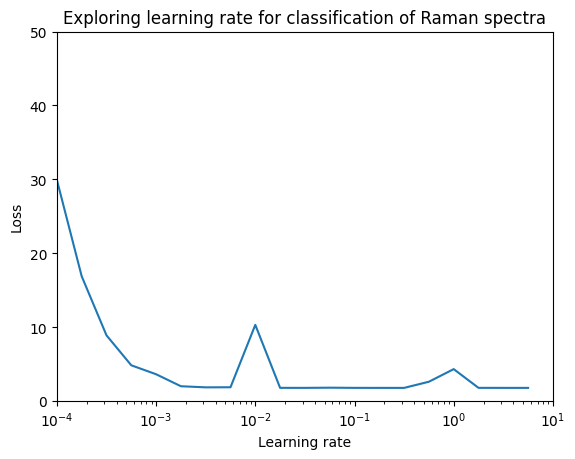

In [12]:
plt.semilogx(lr_history.history["lr"], lr_history.history["loss"])
plt.axis([1e-4, 10, 0, 50])
plt.xlabel('Learning rate')
plt.ylabel('Loss')
plt.title('Exploring learning rate for classification of Raman spectra')

---
### Vary parameters to find best model

The number of dropout units is varied to identify the best model that limits overfitting.

In [13]:
def model_builder(hp):

    hp_units = hp.Int('units', min_value=2, max_value=4, step=2)
    
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv1D(16, (9), activation='relu', input_shape=(2000,2)),
        tf.keras.layers.MaxPooling1D(4),
        tf.keras.layers.Conv1D(32, (7), activation='relu'),
        tf.keras.layers.MaxPooling1D(4), 
        tf.keras.layers.Conv1D(64, (5), activation='relu'), 
        tf.keras.layers.MaxPooling1D(4),
        tf.keras.layers.Conv1D(256, (3), activation='relu'), 
        tf.keras.layers.MaxPooling1D(hp_units),
        # Flatten the results to feed into a DNN
        tf.keras.layers.Flatten(), 
        # 256 neuron hidden layer
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(6, activation='softmax')  
    ])
    
    # Tune the learning rate for the optimizer
    model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])
    
    return(model)

In [14]:
tuner = kt.RandomSearch(model_builder,
                     objective='val_accuracy',
                     directory='my_dir4',
                     project_name='Raman',
                       overwrite=True)


#Stop the training if the validation loss does not improve after epochs
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
tensor_board = tf.keras.callbacks.TensorBoard()


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               
    patience=5,              
    min_lr=1e-6,              
    verbose=1                 
)

tuner.search(training_generator, epochs=50, validation_data = validation_generator, callbacks=[stop_early, tensor_board, reduce_lr])

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

Trial 2 Complete [00h 00m 27s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 54s


In [15]:
print(f"""
The hyperparameter search is complete.\nThe optimal number of dropout units in the first densely-connected layer is
{best_hps.get('units'):.1f}.
""")


The hyperparameter search is complete.
The optimal number of dropout units in the first densely-connected layer is
4.0.



---
### Build the model using the best parameters found earlier

Previously the model weights were saved for the best parameters. They are loaded before the model is further improved by fitting with the data for more epochs.

In [16]:
# Build the model with the optimal hyperparameters and train it on the data for 1000 epochs
model = tuner.hypermodel.build(best_hps)

model_weights = os.path.join(os.getcwd(), 'model_weights')

# Empty directory to prevent FileExistsError is the function is run several times
if os.path.exists(model_weights):
    shutil.rmtree(model_weights)

os.makedirs(model_weights)

model_weights = os.path.join(os.getcwd(), 'model_weights', 'best_model.weights.h5')

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=model_weights,
                                                 save_weights_only=True,
                                                 save_best_only=True,
                                                 verbose=0)

history = model.fit(
            training_generator,
            epochs=100,
            validation_data=validation_generator,
            verbose=1,
            callbacks=[cp_callback, stop_early, reduce_lr]
            )

Epoch 1/100
40/40 [==============================] - 1s 15ms/step - loss: 12.7863 - accuracy: 0.1667 - val_loss: 1.8175 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 2/100
40/40 [==============================] - 1s 13ms/step - loss: 1.8007 - accuracy: 0.1667 - val_loss: 1.8053 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 3/100
40/40 [==============================] - 1s 13ms/step - loss: 1.8026 - accuracy: 0.1833 - val_loss: 1.7959 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 4/100
40/40 [==============================] - 1s 13ms/step - loss: 1.8022 - accuracy: 0.1625 - val_loss: 1.7950 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 5/100
40/40 [==============================] - 1s 13ms/step - loss: 1.7932 - accuracy: 0.1542 - val_loss: 1.7913 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 6/100
40/40 [==============================] - 1s 13ms/step - loss: 1.7942 - accuracy: 0.1625 - val_loss: 1.7913 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 7/100
40/40 [==============================] - 1s 13ms/step - l

---
### Visualize accuracy and loss as a function of epoch

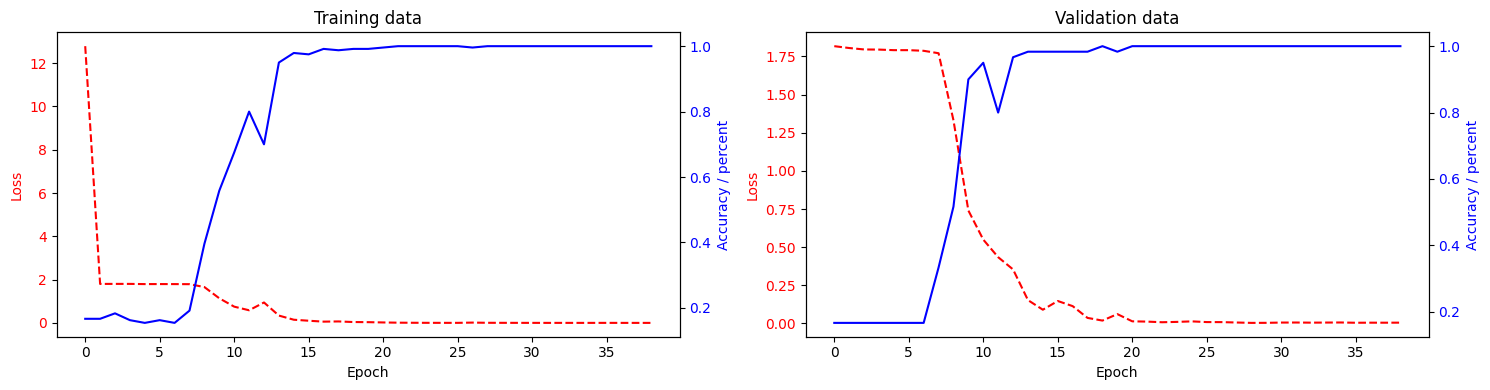

In [17]:
#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

# Visualize loss  and accuracy history
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(15,4))
ax2 = ax[0].twinx()
ax[0].plot(history.history['loss'], 'r--',)
ax2.plot(history.history['accuracy'], 'b-')
ax[0].set_xlabel('Epoch')
ax[0].tick_params(axis='y', labelcolor='r')
ax2.set_ylabel('Accuracy / percent',c='b')
ax[0].set_ylabel('Loss', c='r')
ax2.tick_params(axis='y', labelcolor='b')
ax[0].set_title('Training data')

ax3 = ax[1].twinx()
ax[1].plot(history.history['val_loss'], 'r--',)
ax3.plot(history.history['val_accuracy'], 'b-')
ax[1].set_xlabel('Epoch')
ax[1].tick_params(axis='y', labelcolor='r')
ax3.tick_params(axis='y', labelcolor='b')
ax3.set_ylabel('Accuracy / percent',c='b')
ax[1].set_ylabel('Loss', c='r')
ax[1].set_title('Validation data')
plt.tight_layout()

In [18]:
# Create a basic model instance
model_best = tuner.hypermodel.build(best_hps)

# Loads the weights
model_best.load_weights(model_weights)

# Evaluate the model
loss, acc = model_best.evaluate(validation_generator, verbose=2)
print("Trained model, accuracy: {:5.2f}%".format(100 * acc))

10/10 - 0s - loss: 0.0038 - accuracy: 1.0000 - 208ms/epoch - 21ms/step
Trained model, accuracy: 100.00%


### Evaluate the model

To determine how good the model is a confusion matrix and ROC curve is created

Model evaluation accuracy on validation set: 100.00%

1/1 [==============================] - 0s 10ms/step
Unique classes in y_true: [0 1 2 3 4 5]
Unique classes in y_pred: [0 1 2 3 4 5]
Classification Report:
              precision    recall  f1-score   support

    sample_A       1.00      1.00      1.00        10
    sample_B       1.00      1.00      1.00        10
    sample_C       1.00      1.00      1.00        10
    sample_D       1.00      1.00      1.00        10
    sample_E       1.00      1.00      1.00        10
    sample_F       1.00      1.00      1.00        10

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



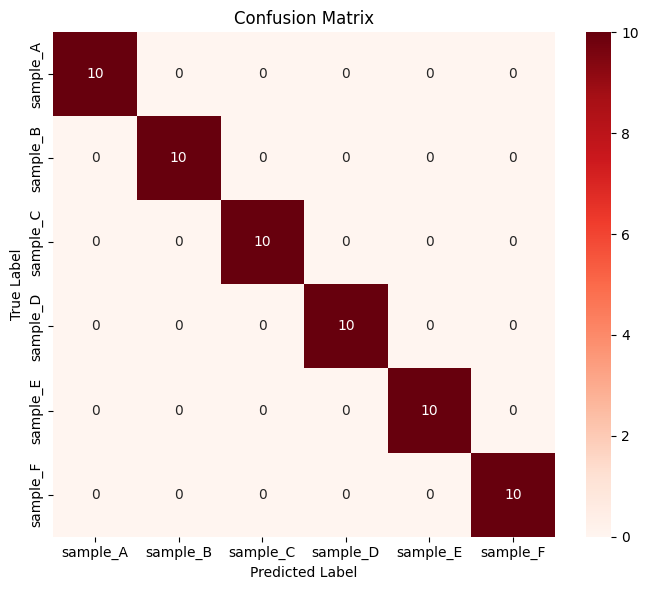

In [19]:
# Evaluate model on validation generator
loss, acc = model_best.evaluate(validation_generator, verbose=0)
print(f"Model evaluation accuracy on validation set: {acc:.2%}\n")


y_true = []
y_pred = []
y_prob = []

for X_batch, y_batch in validation_generator:
    preds = model_best.predict(X_batch)
    y_true.extend(y_batch)
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

print("Unique classes in y_true:", np.unique(y_true))
print("Unique classes in y_pred:", np.unique(y_pred))

# Classification report
class_names = ['sample_A', 'sample_B', 'sample_C', 'sample_D', 'sample_E', 'sample_F']
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
conf_map = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(conf_map, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix_evaluation.png")

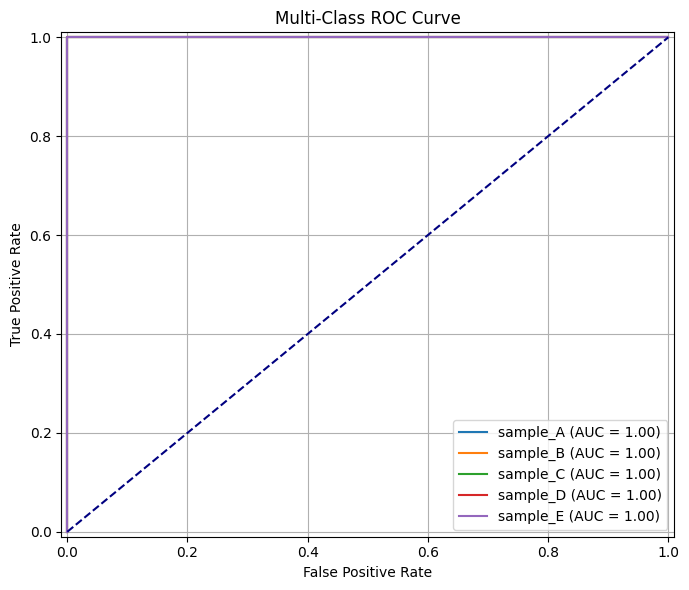

In [20]:
# ROC curve
y_true_bin = label_binarize(y_true, classes=list(range(5)))
plt.figure(figsize=(7, 6))
for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve_evaluation.png")

## Conclusion

This project demonstrates a neural neural network able to classify Raman spectra.